# Extract individual trajectories from one recording

In [8]:
import sys
import numpy as np
sys.path.append("../")
sys.path.append("../src")
sys.path.append("../src/models")
sys.path.append("../src/data")
sys.path.append("../src/utils")
sys.path.append("../src/data/components/")
sys.path.append("../src/models/components/")
sys.path.append("../src/utils/IEBCS")
sys.path.append("../src/utils/IEBCS/representations")
import eventIO

In [2]:
buf = eventIO.load_hdf5("/home/lkolmar/Documents/metavision/recordings/dataset_full_ball-gun/hdf5/" + "spin_0_rec1_converted.hdf5")

Event rates (in ms): [2 0 0 ... 0 0 1]


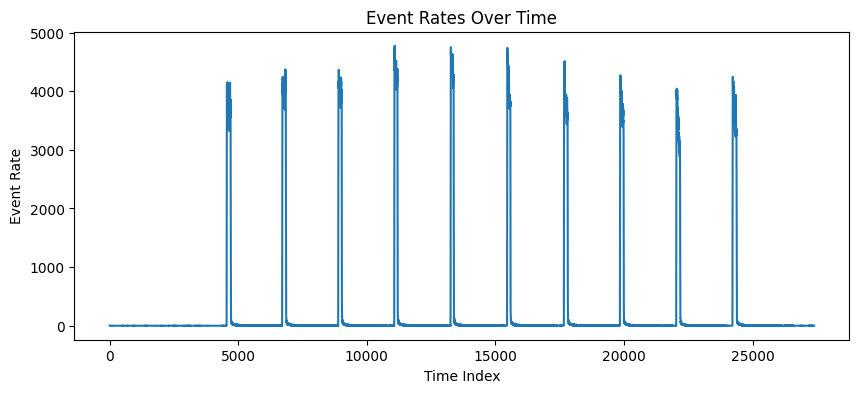

In [7]:
event_rates = buf.ms_to_idx[1:] - buf.ms_to_idx[:-1]
print("Event rates (in ms):", event_rates)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(event_rates)
plt.xlabel("Time Index")
plt.ylabel("Event Rate")
plt.title("Event Rates Over Time")
plt.show()

## Extract timeframes with high event-rates

In [14]:
threshold = 1000  # Set a threshold for event rates (in ms)
high_rate_idxs = np.where(event_rates > threshold)[0]

# Group consecutive indices into individual spikes
spikes = []
if len(high_rate_idxs) > 0:
    current_spike = [high_rate_idxs[0]]
    for idx in high_rate_idxs[1:]:
        if idx == current_spike[-1] + 1:
            current_spike.append(idx)
        else:
            spikes.append(current_spike)
            current_spike = [idx]
    spikes.append(current_spike)

print(len(spikes))
print(spikes[0][0], spikes[0][-1])

10
4551 4712


## Get events for one spike